## Milestone 4

## Data & Preprocessing

### Libraries & Setup

In [3]:
import os
import json
import glob as pyglob
import pandas as pd
from functools import reduce
from IPython.display import display, Markdown

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, LongType,
    BooleanType, ArrayType, DoubleType
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, PCA
)
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

def show(df, n=20):
    display(df.limit(n).toPandas())


In [ ]:
# Expanse Environment (active)
'''
DATA_ROOT = "/expanse/lustre/projects/uci157/kkravchenko/provident-vehicle-detection-at-night-pvdn"
OUTPUT_ROOT = os.path.join(DATA_ROOT, "_m4_outputs")
os.makedirs(OUTPUT_ROOT, exist_ok=True)
'''

# Local Environment
import kagglehub
DATA_ROOT = kagglehub.dataset_download("saralajew/provident-vehicle-detection-at-night-pvdn")
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["PATH"] = "/opt/homebrew/opt/openjdk@17/bin:" + os.environ["PATH"]

In [5]:
# Expanse Environment (active)
'''
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()
'''

# Local Environment
spark = SparkSession.builder \
    .appName("PVDN Milestone 4") \
    .master("local[*]") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "12g") \
    .config("spark.sql.shuffle.partitions", 10) \
    .config("spark.default.parallelism", 10) \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

spark


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/15 15:27:31 WARN Utils: Your hostname, MacBook-Pro-M4Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.66 instead (on interface en0)
26/03/15 15:27:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/15 15:27:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [20]:
# Suppress noisy Spark warnings (plan truncation, netlib BLAS/LAPACK, large broadcast)
spark.sparkContext.setLogLevel("ERROR")
spark.conf.set("spark.sql.debug.maxToStringFields", "500")

### Load Raw Data

In [6]:
base = os.path.join(DATA_ROOT, "PVDN")
ann_paths = sorted(pyglob.glob(os.path.join(base, "*", "*", "labels", "image_annotations.json")))
seq_paths = sorted(pyglob.glob(os.path.join(base, "*", "*", "labels", "sequences.json")))

def add_path_metadata(df, tod_offset, split_offset):
    return df \
        .withColumn("_parts", F.split(F.input_file_name(), "/")) \
        .withColumn("time_of_day", F.element_at(F.col("_parts"), tod_offset)) \
        .withColumn("split", F.element_at(F.col("_parts"), split_offset)) \
        .drop("_parts")

ann_raw = spark.read.option("multiLine", True).json(ann_paths)

images_raw = add_path_metadata(
    ann_raw.select(F.explode("images").alias("img")).select(
        F.col("img.id").alias("image_id"),
        F.col("img.file_name").alias("file_name"),
        F.col("img.height").alias("height"),
        F.col("img.width").alias("width"),
        F.col("img.timestamp").alias("timestamp"),
        F.col("img.camera_configuration").alias("camera_configuration"),
    ), tod_offset=-4, split_offset=-3
)

annotations_df = add_path_metadata(
    ann_raw.select(F.explode("annotations").alias("ann")).select(
        F.col("ann.id").alias("annotation_id"),
        F.col("ann.image_id").alias("image_id"),
        F.col("ann.category").alias("category"),
    ), tod_offset=-4, split_offset=-3
)

images_df = images_raw.join(annotations_df.select("image_id", "category"), on="image_id", how="left")
print(f"images_df rows: {images_df.count()}")
images_df.printSchema()


images_df rows: 59746
root
 |-- image_id: long (nullable = true)
 |-- file_name: string (nullable = true)
 |-- height: long (nullable = true)
 |-- width: long (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- camera_configuration: long (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)
 |-- category: long (nullable = true)



In [7]:
seq_raw = spark.read.option("multiLine", True).json(seq_paths)

sequences_df = add_path_metadata(
    seq_raw.select(F.explode("sequences").alias("seq")).select(
        F.col("seq.id").alias("sequence_id"),
        F.col("seq.image_ids").alias("image_ids"),
        F.col("seq.weather").alias("weather"),
        F.col("seq.road_type").alias("road_type"),
        F.col("seq.direction").alias("direction"),
        F.col("seq.view").alias("view"),
        F.col("seq.street_style").alias("street_style"),
        F.col("seq.proband_behaviour").alias("proband_behaviour"),
        F.col("seq.environment_lighting").alias("environment_lighting"),
        F.col("seq.dome").alias("dome"),
    ), tod_offset=-4, split_offset=-3
)

# Explode image_ids to get one row per image in each sequence
seq_image_map = sequences_df.select(
    F.explode("image_ids").alias("image_id"),
    "weather", "road_type", "direction", "view",
    "street_style", "proband_behaviour", "environment_lighting", "dome",
)

print(f"sequences_df rows: {sequences_df.count()}")
sequences_df.printSchema()


sequences_df rows: 346
root
 |-- sequence_id: long (nullable = true)
 |-- image_ids: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- weather: long (nullable = true)
 |-- road_type: long (nullable = true)
 |-- direction: long (nullable = true)
 |-- view: long (nullable = true)
 |-- street_style: long (nullable = true)
 |-- proband_behaviour: long (nullable = true)
 |-- environment_lighting: long (nullable = true)
 |-- dome: boolean (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- split: string (nullable = true)



In [8]:
kp_dirs = sorted(pyglob.glob(os.path.join(base, "*", "*", "labels", "keypoints")))

vehicle_rows = []
instance_rows = []
blur_rows = []

for kp_dir in kp_dirs:
    parts = kp_dir.replace("\\", "/").split("/")
    time_of_day = parts[-4]
    split_name = parts[-3]
    for fp in sorted(pyglob.glob(os.path.join(kp_dir, "*.json"))):
        with open(fp) as f:
            rec = json.load(f)
        img_id = rec["image_id"]
        for blur in rec.get("blurs", []):
            blur_rows.append((img_id, float(blur[0]), float(blur[1]),
                              float(blur[2]), float(blur[3])))
        for veh in rec.get("annotations", []):
            insts = veh.get("instances", [])
            vehicle_rows.append((
                img_id, veh["pos"], veh["oid"], bool(veh["direct"]), len(insts)
            ))
            for inst in insts:
                instance_rows.append((
                    img_id, veh["oid"], bool(veh["direct"]),
                    inst["pos"], inst["iid"],
                    bool(inst["direct"]), bool(inst["rear"])
                ))

vehicles_df = spark.createDataFrame(vehicle_rows, schema=StructType([
    StructField("image_id", LongType()),
    StructField("vehicle_pos", ArrayType(IntegerType())),
    StructField("vehicle_oid", LongType()),
    StructField("vehicle_direct", BooleanType()),
    StructField("num_instances", IntegerType()),
]))

instances_df = spark.createDataFrame(instance_rows, schema=StructType([
    StructField("image_id", LongType()),
    StructField("vehicle_oid", LongType()),
    StructField("vehicle_direct", BooleanType()),
    StructField("instance_pos", ArrayType(IntegerType())),
    StructField("instance_id", LongType()),
    StructField("instance_direct", BooleanType()),
    StructField("instance_rear", BooleanType()),
]))

blurs_df = spark.createDataFrame(blur_rows, schema=StructType([
    StructField("image_id", LongType()),
    StructField("x1", DoubleType()),
    StructField("y1", DoubleType()),
    StructField("x2", DoubleType()),
    StructField("y2", DoubleType()),
]))

print(f"vehicles_df rows:  {vehicles_df.count()}")
print(f"instances_df rows: {instances_df.count()}")
print(f"blurs_df rows:     {blurs_df.count()}")


vehicles_df rows:  54649
instances_df rows: 157835
blurs_df rows:     2418


### Feature Engineering

| Feature Group | Source | Features |
|---|---|---|
| Vehicle aggregations | `vehicles_df` | `num_vehicles`, `mean_veh_x`, `mean_veh_y`, `num_direct_vehicles` |
| Light instance aggregations | `instances_df` | `num_light_instances`, `mean_inst_x`, `mean_inst_y`, `num_direct_lights`, `num_rear_lights` |
| Blur aggregations | `blurs_df` | `num_blur_regions`, `mean_blur_area` |
| Sequence metadata | `seq_image_map` | `weather`, `road_type`, `direction`, `view`, `street_style`, `proband_behaviour`, `environment_lighting`, `dome` |

In [9]:
veh_agg = vehicles_df.select(
    "image_id",
    F.col("vehicle_pos").getItem(0).alias("veh_x"),
    F.col("vehicle_pos").getItem(1).alias("veh_y"),
    "vehicle_direct",
).groupBy("image_id").agg(
    F.count("*").alias("num_vehicles"),
    F.mean("veh_x").alias("mean_veh_x"),
    F.mean("veh_y").alias("mean_veh_y"),
    F.sum(F.when(F.col("vehicle_direct"), 1).otherwise(0)).alias("num_direct_vehicles"),
)

inst_agg = instances_df.select(
    "image_id",
    F.col("instance_pos").getItem(0).alias("inst_x"),
    F.col("instance_pos").getItem(1).alias("inst_y"),
    "instance_direct",
    "instance_rear",
).groupBy("image_id").agg(
    F.count("*").alias("num_light_instances"),
    F.mean("inst_x").alias("mean_inst_x"),
    F.mean("inst_y").alias("mean_inst_y"),
    F.sum(F.when(F.col("instance_direct"), 1).otherwise(0)).alias("num_direct_lights"),
    F.sum(F.when(F.col("instance_rear"), 1).otherwise(0)).alias("num_rear_lights"),
)

blur_agg = blurs_df.withColumn(
    "blur_area", (F.col("x2") - F.col("x1")) * (F.col("y2") - F.col("y1"))
).groupBy("image_id").agg(
    F.count("*").alias("num_blur_regions"),
    F.mean("blur_area").alias("mean_blur_area"),
)

print("Vehicle aggregations:")
show(veh_agg, 5)
print("Instance aggregations:")
show(inst_agg, 5)
print("Blur aggregations:")
show(blur_agg, 5)


Vehicle aggregations:


,image_id,num_vehicles,mean_veh_x,mean_veh_y,num_direct_vehicles
0,8489,1,677.0,557.0,0
1,8525,1,637.0,573.0,1
2,8543,1,601.0,579.0,1
3,8561,2,612.0,583.5,1
4,8569,2,599.0,585.5,2


Instance aggregations:


,image_id,num_light_instances,mean_inst_x,mean_inst_y,num_direct_lights,num_rear_lights
0,8489,2,677.000000,552.500000,2,0
1,8525,7,649.714286,567.142857,4,0
2,8543,7,618.571429,568.571429,4,0
3,8561,9,603.888889,570.666667,6,0
4,8569,10,605.900000,573.500000,6,0


Blur aggregations:


,image_id,num_blur_regions,mean_blur_area
0,8581,1,45.0
1,8615,1,1462.0
2,54044,1,3536.0
3,81363,2,188.0
4,81371,2,217.5


In [10]:
model_df = images_df.select("image_id", "category", "split") \
    .join(veh_agg,  on="image_id", how="left") \
    .join(inst_agg, on="image_id", how="left") \
    .join(blur_agg, on="image_id", how="left") \
    .join(seq_image_map, on="image_id", how="left")

print(f"model_df rows: {model_df.count()}")
model_df.printSchema()


model_df rows: 59746
root
 |-- image_id: long (nullable = true)
 |-- category: long (nullable = true)
 |-- split: string (nullable = true)
 |-- num_vehicles: long (nullable = true)
 |-- mean_veh_x: double (nullable = true)
 |-- mean_veh_y: double (nullable = true)
 |-- num_direct_vehicles: long (nullable = true)
 |-- num_light_instances: long (nullable = true)
 |-- mean_inst_x: double (nullable = true)
 |-- mean_inst_y: double (nullable = true)
 |-- num_direct_lights: long (nullable = true)
 |-- num_rear_lights: long (nullable = true)
 |-- num_blur_regions: long (nullable = true)
 |-- mean_blur_area: double (nullable = true)
 |-- weather: long (nullable = true)
 |-- road_type: long (nullable = true)
 |-- direction: long (nullable = true)
 |-- view: long (nullable = true)
 |-- street_style: long (nullable = true)
 |-- proband_behaviour: long (nullable = true)
 |-- environment_lighting: long (nullable = true)
 |-- dome: boolean (nullable = true)



### Preprocessing Pipeline

| Stage | Transformer | Purpose |
|---|---|---|
| 1 | `Imputer` (mean strategy) | Fill NaN in numeric columns for images with no vehicles/blurs |
| 2 | `StringIndexer` × 8 | Encode integer-coded categorical fields to label indices |
| 3 | `OneHotEncoder` | Expand label indices to sparse binary vectors |
| 4 | `VectorAssembler` | Concatenate all numeric + encoded features into one feature vector |
| 5 | `StandardScaler` | Normalize to zero mean, unit variance |

In [ ]:
categorical_cols = [
    "weather", "road_type", "direction", "view",
    "street_style", "proband_behaviour", "environment_lighting", "dome"
]
for c in categorical_cols:
    model_df = model_df.withColumn(c, F.col(c).cast(StringType()))

numeric_cols = [
    "mean_veh_x", "mean_veh_y",
    "num_light_instances", "mean_inst_x", "mean_inst_y", "num_direct_lights", "num_rear_lights",
    "num_blur_regions", "mean_blur_area",
]

for c in numeric_cols:
    model_df = model_df.withColumn(c, F.col(c).cast(DoubleType()))

print("Sample rows from model_df:")
show(model_df.select(["image_id", "category"] + numeric_cols[:5]), 5)


Sample rows from model_df:


,image_id,category,mean_veh_x,mean_veh_y,num_light_instances,mean_inst_x,mean_inst_y
0,1,0,NaN,NaN,NaN,NaN,NaN
1,3,0,NaN,NaN,NaN,NaN,NaN
2,5,0,NaN,NaN,NaN,NaN,NaN
3,7,0,NaN,NaN,NaN,NaN,NaN
4,9,0,NaN,NaN,NaN,NaN,NaN


In [12]:
imputed_cols = [c + "_imputed" for c in numeric_cols]
imputer = Imputer(
    strategy="mean",
    inputCols=numeric_cols,
    outputCols=imputed_cols,
)

indexed_cols = [c + "_idx" for c in categorical_cols]
string_indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_idx",
        handleInvalid="keep",
    )
    for c in categorical_cols
]

ohe_cols = [c + "_ohe" for c in categorical_cols]
ohe = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=ohe_cols,
    dropLast=True,
)

assembler = VectorAssembler(
    inputCols=imputed_cols + ohe_cols,
    outputCol="features_raw",
    handleInvalid="keep",
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True,
)

preprocessing_pipeline = Pipeline(stages=[
    imputer,
    *string_indexers,
    ohe,
    assembler,
    scaler,
])

print(f"Pipeline stages: {len(preprocessing_pipeline.getStages())}")


Pipeline stages: 12


### Train / Test Split

In [13]:
train_df = model_df.filter(F.col("split") == "train")
val_df   = model_df.filter(F.col("split") == "val")
test_df  = model_df.filter(F.col("split") == "test")

print(f"Train rows: {train_df.count()}")
print(f"Val rows:   {val_df.count()}")
print(f"Test rows:  {test_df.count()}")

display(Markdown("**Train category distribution:**"))
show(train_df.groupBy("category").agg(F.count("*").alias("count")).orderBy("category"))


Train rows: 44342
Val rows:   8220
Test rows:  7184


**Train category distribution:**

,category,count
0,0,11288
1,1,110
2,2,2701
3,3,73
4,4,912
5,5,73
6,6,29185


### Reflection label and sample weights

Binary label and class weights for the PCA+RF pipeline


In [14]:
def add_reflection_label(df):
    num_vehicles = F.coalesce(F.col("num_vehicles"), F.lit(0.0))
    num_direct   = F.coalesce(F.col("num_direct_vehicles"), F.lit(0.0))
    num_indirect = num_vehicles - num_direct
    return (df
        .withColumn("num_indirect_vehicles", num_indirect)
        .withColumn("label_reflection", (F.col("num_indirect_vehicles") > 0).cast("double"))
    )

train_with_label = add_reflection_label(train_df)
n_train = train_with_label.count()
label_counts = train_with_label.groupBy("label_reflection").count()
K = 2
label_weights = label_counts.withColumn(
    "sample_weight",
    F.lit(n_train) / (F.lit(K) * F.col("count"))
).select("label_reflection", "sample_weight")

print("Reflection label distribution (train):")
train_with_label.groupBy("label_reflection").count().show()


Reflection label distribution (train):
+----------------+-----+
|label_reflection|count|
+----------------+-----+
|             0.0|27927|
|             1.0|16415|
+----------------+-----+



---
## Task 1: Dimensionality Reduction & Random Forest

PCA on scaled features & RandomForest on `pca_features`.

In [26]:
pca = PCA(
    k=10,
    inputCol="features",
    outputCol="pca_features"
)
preprocessing_pipeline_m2 = Pipeline(stages=[
    imputer,
    *string_indexers,
    ohe,
    assembler,
    scaler,
    pca
])

preprocessing_model_m2 = preprocessing_pipeline_m2.fit(train_df)
train_transformed_m2 = preprocessing_model_m2.transform(train_df)
val_transformed_m2   = preprocessing_model_m2.transform(val_df)
test_transformed_m2  = preprocessing_model_m2.transform(test_df)

train_ref_pca = add_reflection_label(train_transformed_m2)
val_ref_pca   = add_reflection_label(val_transformed_m2)
test_ref_pca  = add_reflection_label(test_transformed_m2)

train_ref_pca = train_ref_pca.join(label_weights, on="label_reflection", how="left")
val_ref_pca   = val_ref_pca.join(label_weights, on="label_reflection", how="left")
test_ref_pca  = test_ref_pca.join(label_weights, on="label_reflection", how="left")

rf_pca = RandomForestClassifier(
    labelCol="label_reflection",
    featuresCol="pca_features",
    weightCol="sample_weight",
    numTrees=200,
    maxDepth=8,
    seed=42
)
model_rf_pca = rf_pca.fit(train_ref_pca)

print("PCA k=10 + RF trained.")
print("Explained variance:", preprocessing_model_m2.stages[-1].explainedVariance)

PCA k=10 + RF trained.
Explained variance: [0.11440155346974433,0.0914385229597303,0.07718056148695984,0.06254213556327452,0.05760271233258632,0.05369996904158331,0.050089325865530776,0.047126325641063845,0.042995985334054444,0.04089829447399555]


---
## Model Evaluation & Explained Variance


In [29]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

auc_eval = BinaryClassificationEvaluator(
    labelCol="label_reflection",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label_reflection",
    predictionCol="prediction",
    metricName="accuracy"
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label_reflection",
    predictionCol="prediction",
    metricName="f1"
)

eval_results = []

def evaluate(model, df, model_label, split_name):
    pred = model.transform(df)
    auc = auc_eval.evaluate(pred)
    acc = acc_eval.evaluate(pred)
    f1  = f1_eval.evaluate(pred)
    eval_results.append({"Model": model_label, "Split": split_name,
                         "AUC": round(auc, 4), "Accuracy": round(acc, 4), "F1": round(f1, 4)})
    print(f"{split_name}: AUC={auc:.4f} | Acc={acc:.4f} | F1={f1:.4f}")
    return pred

print("=== RF-PCA (k=10, numTrees=200, maxDepth=8) ===")
evaluate(model_rf_pca, train_ref_pca, "RF-PCA (k=10)", "Train")
evaluate(model_rf_pca, val_ref_pca,   "RF-PCA (k=10)", "Val")
evaluate(model_rf_pca, test_ref_pca,  "RF-PCA (k=10)", "Test")

display(Markdown("**RF-PCA metrics:**"))
display(pd.DataFrame(eval_results))

=== RF-PCA (k=10, numTrees=200, maxDepth=8) ===


Train: AUC=0.9721 | Acc=0.9180 | F1=0.9179
Val: AUC=0.9292 | Acc=0.8585 | F1=0.8599
Test: AUC=0.8562 | Acc=0.8030 | F1=0.7972


**RF-PCA metrics:**

,Model,Split,AUC,Accuracy,F1
0,RF-PCA (k=10),Train,0.9721,0.9180,0.9179
1,RF-PCA (k=10),Val,0.9292,0.8585,0.8599
2,RF-PCA (k=10),Test,0.8562,0.8030,0.7972


### Train vs test performance

Compare training and test metrics to assess overfitting (train–test gap).

In [ ]:
df = pd.DataFrame(eval_results)
train_row = df[(df["Model"].str.contains("RF-PCA", na=False)) & (df["Split"] == "Train")].iloc[0]
test_row  = df[(df["Model"].str.contains("RF-PCA", na=False)) & (df["Split"] == "Test")].iloc[0]

train_acc, test_acc = train_row["Accuracy"], test_row["Accuracy"]
train_f1,  test_f1  = train_row["F1"], test_row["F1"]
gap_acc = train_acc - test_acc
gap_f1  = train_f1 - test_f1

comparison = pd.DataFrame([
    {"Metric": "Accuracy", "Train": train_acc, "Test": test_acc, "Gap (Train − Test)": round(gap_acc, 4)},
    {"Metric": "F1",       "Train": train_f1,  "Test": test_f1,  "Gap (Train − Test)": round(gap_f1, 4)},
])
display(Markdown("**RF-PCA (k=10): Train vs test**"))
display(comparison)
print(f"Train–test accuracy gap: {gap_acc:.4f}.")

**RF-PCA (k=10): Train vs test**

,Metric,Train,Test,Gap (Train − Test)
0,Accuracy,0.9180,0.8030,0.1150
1,F1,0.9179,0.7972,0.1207


Train–test accuracy gap: 0.1150.


### Explained variance (PCA)

Per-component and cumulative explained variance for the 10 principal components. Reports how much variance is retained by the chosen `k`.

Cumulative variance retained: 63.80%
Per-PC variance (%): [11.44, 9.14, 7.72, 6.25, 5.76, 5.37, 5.01, 4.71, 4.3, 4.09]


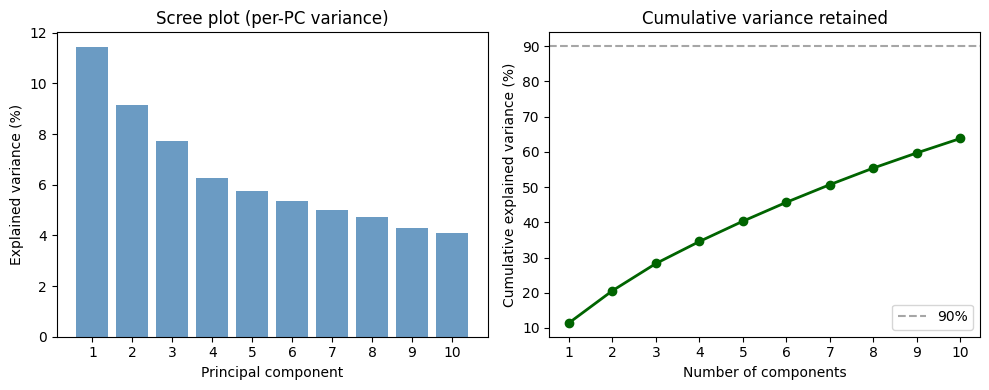

In [28]:
import matplotlib.pyplot as plt
import numpy as np

pca_model = preprocessing_model_m2.stages[-1]
ev = np.array(pca_model.explainedVariance)
k = len(ev)
cumvar = np.cumsum(ev)
var_pct = 100 * ev
cumvar_pct = 100 * cumvar

print(f"Cumulative variance retained: {cumvar_pct[-1]:.2f}%")
print("Per-PC variance (%):", np.round(var_pct, 2).tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(range(1, k + 1), var_pct, color="steelblue", alpha=0.8)
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance (%)")
ax1.set_title("Scree plot (per-PC variance)")
ax1.set_xticks(range(1, k + 1))

ax2.plot(range(1, k + 1), cumvar_pct, "o-", color="darkgreen", linewidth=2)
ax2.axhline(y=90, color="gray", linestyle="--", alpha=0.7, label="90%")
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance (%)")
ax2.set_title("Cumulative variance retained")
ax2.legend()
ax2.set_xticks(range(1, k + 1))
plt.tight_layout()
plt.show()

---
## Fitting Analysis
Our initial thought when compared to Model 1 from milestone 3 (a near ideal fit). We noticed Model 2 has more overfitting + lower performance after PCA
because it had Train Accuracy = 0.9180 Test Accuracy = 0.8030 making the gap 0.1150

Which is much larger.
The second model falls in the moderate overfitting region of the fitting graph. The PCA + Random Forest pipeline achieved strong training performance, with AUC = 0.9721, accuracy = 0.9180, and F1 = 0.9179, but performance decreased on the test set to AUC = 0.8562, accuracy = 0.8030, and F1 = 0.7972. The train test accuracy gap of 0.1150 and F1 gap of 0.1207 indicate that the model learned useful patterns from the training data but does not generalize as well to unseen examples. 

Compared with Model 1, the second model shows noticeably more overfitting. In Model 1, the Random Forest trained on the full feature set achieved 0.9225 training accuracy and 0.9116 test accuracy, producing a very small gap of 0.0109, which places Model 1 close to the ideal fit region. This means the full feature model generalized much better than the PCA based model.

Dimensionality reduction affected the results by simplifying the feature space before classification. PCA reduced the data to 10 principal components, retaining 63.80% of the total variance. While this reduced dimensional complexity, it also removed approximately 36% of the original variance, which likely contained useful predictive information. This loss of information appears to be one reason why Model 2 performed worse than Model 1 on unseen data.
On the fitting graph, Model 2 sits further toward the high-variance side than Model 1. Although training performance remains strong, the larger drop in test accuracy shows that the reduced feature representation does not preserve all of the predictive structure available in the full dataset.

Future improvements could include testing a larger number of principal components, such as 15, 20, or 30, to retain more variance while still reducing dimensionality. Another possible next step would be comparing PCA with SVD, since SVD may preserve feature relationships differently in high dimensional data. Additional hyperparameter tuning of the Random Forest may also reduce overfitting.

---
## Conclusion
Our final thoughts 

When comparing Model 1 and Model 2 we concluded that dimensionality reduction does not always improve predictive performance. Model 1, used the full feature set with Random Forest, achieved stronger generalization with 0.9116 test accuracy, while Model 2, used PCA with Random Forest, reached 0.8030 test accuracy and showed a larger train test gap. Although PCA reduced the feature space to 10 principal components and retained 63.80% of total variance, some useful predictive information was lost.

This indicates that the original feature set contained important relationships that were not fully preserved after dimensionality reduction. PCA reduced complexity and improved feature compression, but the lower test performance shows that simplification alone did not improve classification quality.

To improve Model 2, additional testing with more PCA components such as 15, 20, or 30 could help retain more variance. Comparing PCA with SVD may also improve feature representation. Further Random Forest hyperparameter tuning could reduce overfitting and improve generalization.

This project helped our team learn that having distributed computing access can make large-scale modeling possible, but model quality still depends on feature selection and evaluation rather than computational power alone.

---
## Prediction Analysis


In [ ]:
predictions.select("label", "prediction", "probability").show(10, truncate=False) 

In [ ]:
#True prediction 
predictions.filter(predictions.label == predictions.prediction)\
    .select("label", "prediction", "probability")\
    .show(3, truncate=False)


In [ ]:
#False positives 
predictions.filter((predictions.label == 0) & (predictions.prediction == 1))\
    .select("label", "prediction", "probability")\
    .show(3, truncate=False)

#False negatives 
predictions.filter((predictions.label == 1) & (predictions.prediction == 0))\
    .select("label", "prediction", "probability")\
    .show(3, truncate=False)

In [ ]:
spark.stop()
